In [1]:
import os
import torch
from torch import nn
from models import ClsModel
from torch.utils import data
import metrics
from config import SEED, TRAIN_BS, VAL_BS, COLORED_PROPORTION, CLS_EPOCHS, RUN_NAME
import train_utils
import plot_utils
import matplotlib.pyplot as plt
import datetime

In [2]:
plt.style.use('default')

In [3]:
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps"

In [4]:
metrics_calculator = metrics.MetricsCalculator(num_classes=10)
metrics_calculator.reset()

In [5]:
train_dataset = torch.load("./data/train_dataset.pt", weights_only=False)
val_dataset = torch.load("./data/val_dataset.pt", weights_only=False)
clean_val_dataset = torch.load("./data/clean_val_dataset.pt", weights_only=False)
fully_colored_val_dataset = torch.load("./data/fully_colored_val_dataset.pt", weights_only=False)
colors_flipped_val_dataset = torch.load("./data/colors_flipped_val_dataset.pt", weights_only=False)

Training:   0%|          | 0/1500 [00:00<?, ?it/s]/Users/jakub/ml/sae/Sparse-Autoencoders-for-Vision-in-Pytorch/.venv/lib/python3.12/site-packages/torcheval/metrics/functional/classification/accuracy.py:275: UserWarning: The reduce argument of torch.scatter with Tensor src is deprecated and will be removed in a future PyTorch release. Use torch.scatter_reduce instead for more reduction options. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorAdvancedIndexing.cpp:228.)
  num_correct = mask.new_zeros(num_classes).scatter_(0, target, mask, reduce="add")
Evaluating: 100%|██████████| 375/375 [00:01<00:00, 369.36it/s]


Epoch 1/10 - Train Loss: 0.006992, Val Loss: 0.001664, Accuracy: 0.990316, Precision: 0.990316, Recall: 0.990316, F1 Score: 0.990203, AUPRC: 0.997587, AUROC: 0.999434


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 348.65it/s]


Epoch 2/10 - Train Loss: 0.001364, Val Loss: 0.001168, Accuracy: 0.991055, Precision: 0.991055, Recall: 0.991055, F1 Score: 0.991028, AUPRC: 0.998052, AUROC: 0.999483


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 351.01it/s]


...

Epoch 8/10 - Train Loss: 0.000344, Val Loss: 0.000787, Accuracy: 0.992845, Precision: 0.992845, Recall: 0.992845, F1 Score: 0.992797, AUPRC: 0.998452, AUROC: 0.999534


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 364.84it/s]


Epoch 9/10 - Train Loss: 0.000275, Val Loss: 0.000790, Accuracy: 0.992200, Precision: 0.992200, Recall: 0.992200, F1 Score: 0.992200, AUPRC: 0.998385, AUROC: 0.999553


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 338.53it/s]


Epoch 10/10 - Train Loss: 0.000231, Val Loss: 0.000708, Accuracy: 0.993355, Precision: 0.993355, Recall: 0.993355, F1 Score: 0.993308, AUPRC: 0.998565, AUROC: 0.999595


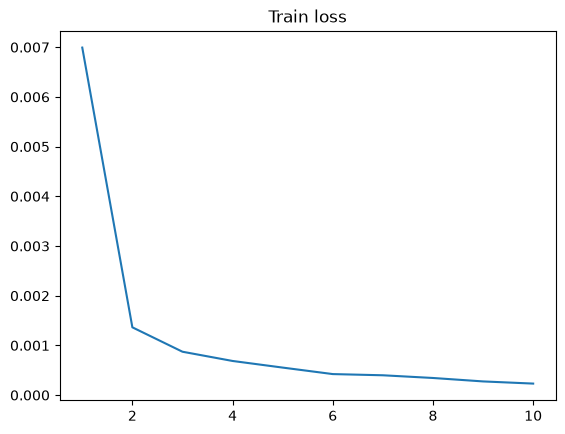

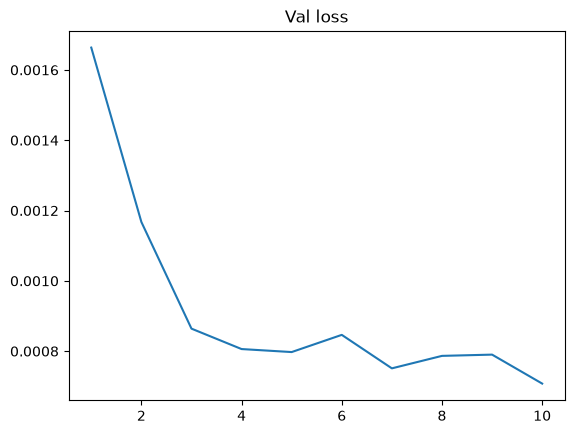

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 308.92it/s]

Performance on clean validation set:
Clean Val Loss: 0.0146, Accuracy: 0.8698, Precision: 0.8698, Recall: 0.8698, F1 Score: 0.8696, AUPRC: 0.9161, AUROC: 0.9794
Performance on fully colored validation set:
Fully Colored Val Loss: 0.0001, Accuracy: 0.9988, Precision: 0.9988, Recall: 0.9988, F1 Score: 0.9987, AUPRC: 0.9998, AUROC: 0.9999
Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.1509, Accuracy: 0.3181, Precision: 0.3181, Recall: 0.3181, F1 Score: 0.2966, AUPRC: 0.3592, AUROC: 0.7136


In [6]:
train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
fully_colored_val_dataloader = data.DataLoader(fully_colored_val_dataset, batch_size=VAL_BS)
colors_flipped_val_dataloader = data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS)

model = ClsModel()
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Train the model
train_losses, val_losses = train_utils.cls_train(model, train_dataloader, val_dataloader, criterion, optimizer, metrics_calculator, device=device, epochs=CLS_EPOCHS)

# Plot results
plot_utils.plot_loss(train_losses, "Train loss")
plot_utils.plot_loss(val_losses, "Val loss")

# Evaluate the model on clean validation dataset
clean_val_loss = train_utils.cls_evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
fully_colored_val_loss = train_utils.cls_evaluate(model, fully_colored_val_dataloader, criterion, metrics_calculator, device)
fully_colored_val_accuracy, fully_colored_val_precision, fully_colored_val_recall, fully_colored_val_f1_score, fully_colored_val_auprc, fully_colored_val_auroc = metrics_calculator.compute_all()

colors_flipped_val_loss = train_utils.cls_evaluate(model, colors_flipped_val_dataloader, criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
print("Performance on fully colored validation set:")
print(f"Fully Colored Val Loss: {fully_colored_val_loss:.4f}, Accuracy: {fully_colored_val_accuracy:.4f}, Precision: {fully_colored_val_precision:.4f}, Recall: {fully_colored_val_recall:.4f}, F1 Score: {fully_colored_val_f1_score:.4f}, AUPRC: {fully_colored_val_auprc:.4f}, AUROC: {fully_colored_val_auroc:.4f}")

print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss:.4f}, Accuracy: {colors_flipped_val_accuracy:.4f}, Precision: {colors_flipped_val_precision:.4f}, Recall: {colors_flipped_val_recall:.4f}, F1 Score: {colors_flipped_val_f1_score:.4f}, AUPRC: {colors_flipped_val_auprc:.4f}, AUROC: {colors_flipped_val_auroc:.4f}")


In [ ]:
time = datetime.datetime.now()
os.makedirs(os.path.join("weights", RUN_NAME), exist_ok=True)
torch.save(model.state_dict(), os.path.join(f"weights", RUN_NAME, "cls_model.pt"))